In [1]:
%config InlineBackend.figure_format = 'retina'

from pathlib import Path
import os
import sys
import matplotlib.pyplot as plt
import numpy as np

os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src import load_image, population, rendering
from src.ga import GeneticAlgorithm, fitness, mutate, cross_over


In [2]:
individual = population.create_random_individual()
individual[:5]

[Triangle(x1=2, y1=227, x2=130, y2=207, x3=3, y3=95, r=84, g=216, b=55, a=255),
 Triangle(x1=44, y1=249, x2=134, y2=200, x3=298, y3=272, r=189, g=137, b=129, a=109),
 Triangle(x1=32, y1=20, x2=165, y2=214, x3=248, y3=8, r=202, g=102, b=121, a=25),
 Triangle(x1=116, y1=343, x2=43, y2=190, x3=119, y3=367, r=189, g=159, b=121, a=225),
 Triangle(x1=174, y1=244, x2=295, y2=307, x3=148, y3=12, r=12, g=161, b=61, a=204)]

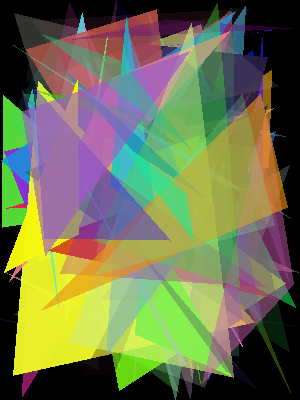

In [3]:
random_image = rendering.render_individual(individual=individual)
random_image

This random initialization confirms that the representation and rendering pipeline are functioning correctly.


In [4]:
# --- Import original paiting image --- #
image_path = os.path.join(project_root, "images/girl_pearl_earing.png")
target_array = load_image.load_target_image(image_path)
print(f"{target_array.shape} -> (H, W, 3) array with RGB values in [0, 255]")

(400, 300, 3) -> (H, W, 3) array with RGB values in [0, 255]


In [5]:
# --- Convert random first image to matrix and compute RMSE --- #
first_target_array = rendering.image_to_array(random_image)
fitness.compute_rmse(target=target_array, generated=first_target_array)

0.3212319612503052

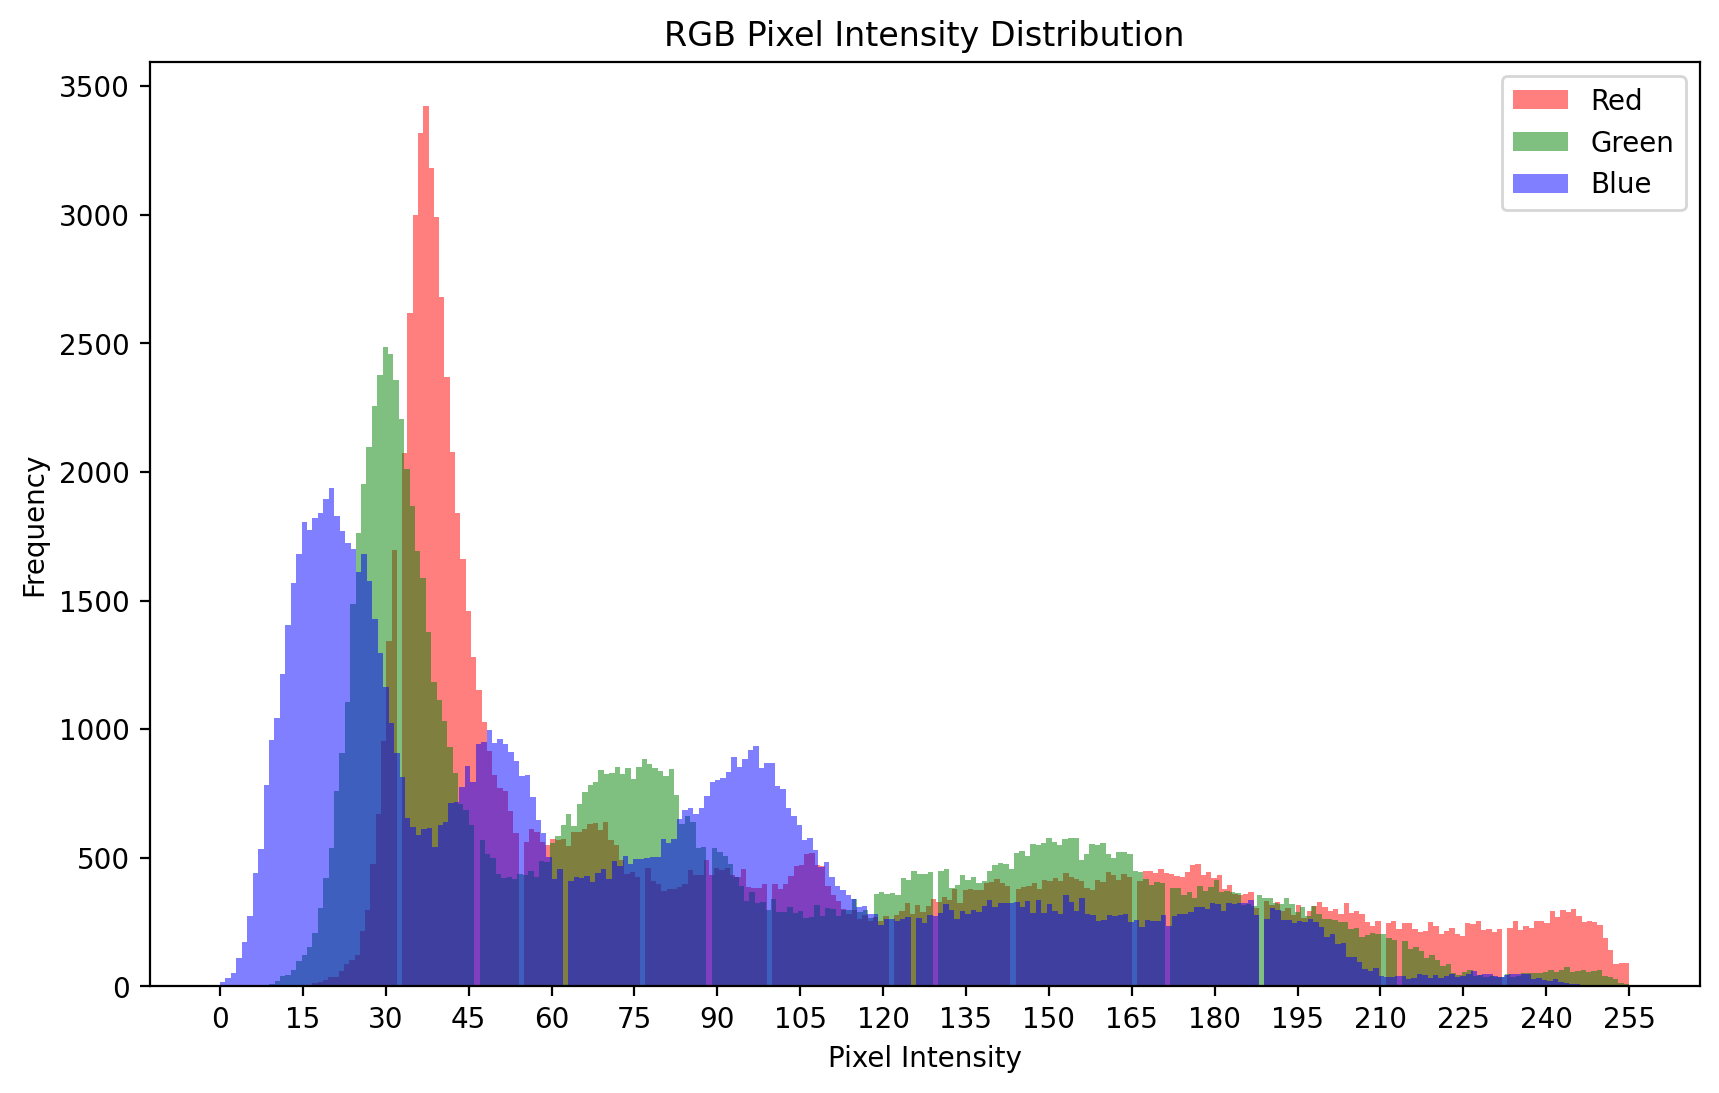

In [6]:
# Separate channels
r = target_array[:, :, 0].flatten()
g = target_array[:, :, 1].flatten()
b = target_array[:, :, 2].flatten()

# Plot histograms
plt.figure(figsize=(10, 6))
plt.hist(r, bins=256, color="red", alpha=0.5, label="Red")
plt.hist(g, bins=256, color="green", alpha=0.5, label="Green")
plt.hist(b, bins=256, color="blue", alpha=0.5, label="Blue")

plt.xticks(np.arange(0, 256, 15))  # ticks every 25
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.title("RGB Pixel Intensity Distribution")
plt.legend()
plt.show()

Building greedy individual (100 triangles, 200 candidates each)...
  greedy: placed 10/100 triangles  RMSE=0.2276
  greedy: placed 20/100 triangles  RMSE=0.2064
  greedy: placed 30/100 triangles  RMSE=0.1895
  greedy: placed 40/100 triangles  RMSE=0.2001
  greedy: placed 50/100 triangles  RMSE=0.1882
  greedy: placed 60/100 triangles  RMSE=0.1777
  greedy: placed 70/100 triangles  RMSE=0.1682
  greedy: placed 80/100 triangles  RMSE=0.1626
  greedy: placed 90/100 triangles  RMSE=0.1780
  greedy: placed 100/100 triangles  RMSE=0.1816
Greedy population ready (200 individuals).
[GA] gen 1/500 | best=0.177428 | gen_best=0.180447 | mut_rate=0.2200 | mutated_offspring=190 | mutated_triangles=4235
[GA] gen 11/500 | best=0.165485 | gen_best=0.180447 | mut_rate=0.2166 | mutated_offspring=190 | mutated_triangles=4125
[GA] gen 21/500 | best=0.161487 | gen_best=0.180447 | mut_rate=0.2200 | mutated_offspring=190 | mutated_triangles=4195
[GA] gen 31/500 | best=0.158000 | gen_best=0.180447 | mut_rate=

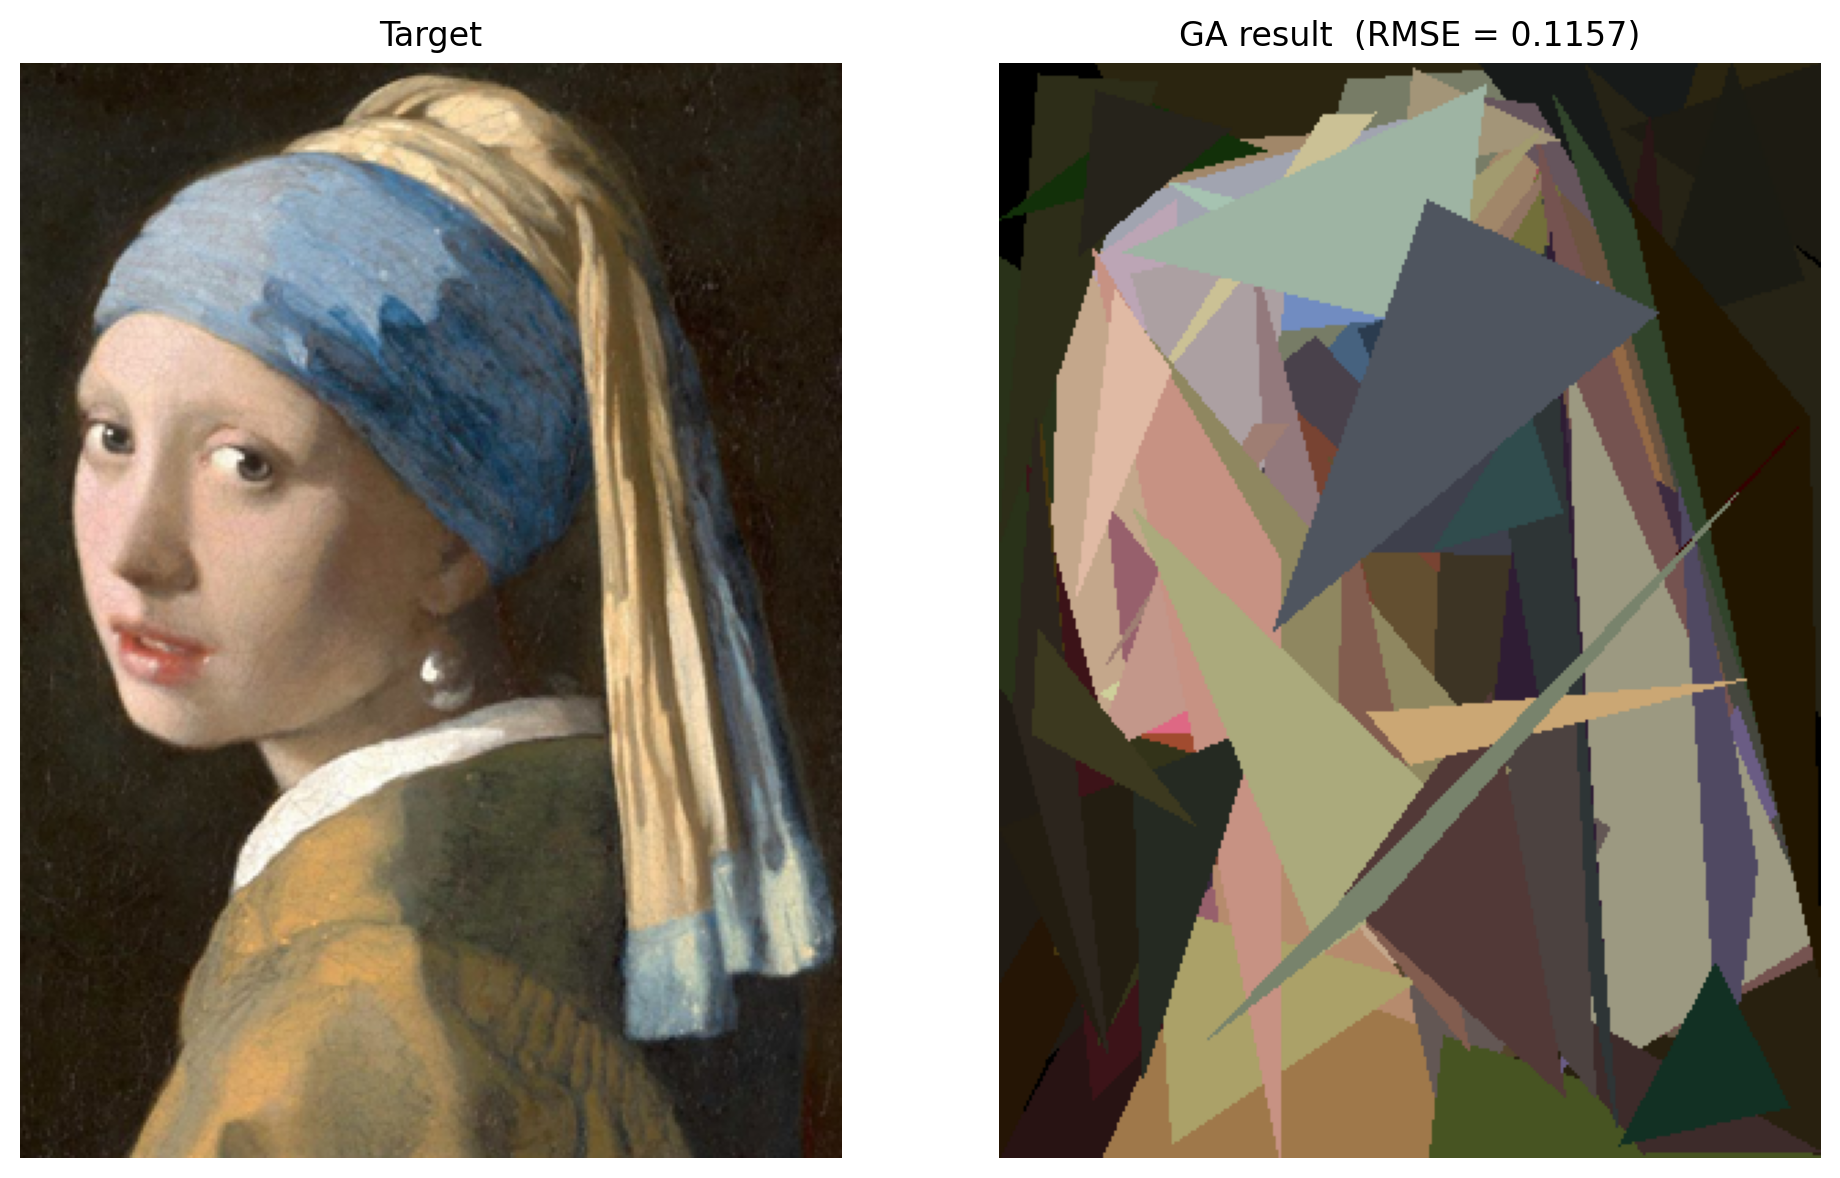

In [ ]:
from src.ga import create_greedy_seeded_population
import matplotlib.pyplot as plt
import numpy as np

# Greedy initialization: tries 200 random triangles per slot and keeps the best.
# Takes ~30-60s but gives a much better starting point than random.
greedy_population = create_greedy_seeded_population(
    target=target_array,
    population_size=200,
    n_triangles=100,
    image_width=300,
    image_height=400,
    candidates_per_triangle=200,
    verbose=True,
)

ga = GeneticAlgorithm(
    target=target_array,
    triangle_alpha_range=(255, 255),
    fitness_function=fitness.compute_rmse,
    population_size=200,
    generations=500,
    crossover_function=cross_over.two_point_crossover,
    crossover_rate=0.85,
    mutation_function=mutate.focused_triangle_mutation,
    mutation_rate=0.12,
    elitism=5,
    selection_type="tournament",
    adaptive_mutation=True,
    mutation_rate_bounds=(0.05, 0.22),
    stagnation_window=15,
    random_immigrants=5,
    initial_population=greedy_population,
    local_search_steps=30,
    logs=True,
    evaluation_backend="process",
    n_jobs=8,
    chunksize=5,
    progress=True,
    progress_interval=10,
    max_edge_length=50,
)

best_fitness, history = ga.run()
best_individual = ga.best_individual

print(f"GA best fitness (RMSE): {best_fitness:.6f}")

result_image = rendering.render_individual(
    best_individual,
    image_width=target_array.shape[1],
    image_height=target_array.shape[0],
)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(target_array.astype(np.uint8))
axes[0].set_title("Target")
axes[0].axis("off")
axes[1].imshow(result_image)
axes[1].set_title(f"GA result  (RMSE = {best_fitness:.4f})")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [8]:
# Output the best fitness and display the best individual's image
print(f"Best Fitness: {best_fitness}")  

Best Fitness: 0.11568571627140045


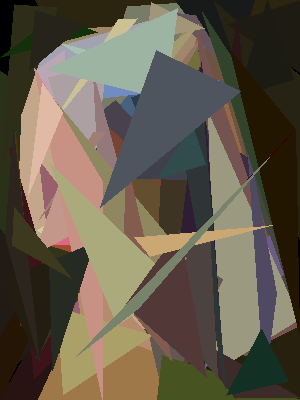

In [9]:
rendering.render_individual(individual=ga.best_individual)

In [ ]:
from src.ga import LegacyPipelineConfig, run_legacy_pipeline, fitness

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
image_path = project_root / "images/girl_pearl_earing.png"  # change if needed
target_image = load_image.load_target_image(image_path)

legacy_config = LegacyPipelineConfig(
    population_size=200,
    generations=400,
    n_triangles=100,
    elitism_fraction=0.2,
    tournament_size=3,
    mutation_rate=0.15,
    position_sigma=0.05,
    color_sigma=0.08,
    stagnation_boost_window=15,
    diversity_window=30,
    local_search_steps=50,
    evaluation_backend="process",  # or "sequential" / "thread"
    n_jobs=8,
    chunksize=8,
    seed=42,
    progress=True,
    progress_interval=10,
)

legacy_result = run_legacy_pipeline(
    target=target_image,
    config=legacy_config,
    fitness_function=fitness.compute_rmse,
)

best_fitness = legacy_result.best_fitness
history = legacy_result.history
best_individual = legacy_result.best_individual
generation_logs = legacy_result.generation_logs

Building greedy individual (100 triangles, 200 candidates each)...
  greedy: placed 10/100 triangles  RMSE=0.2259
  greedy: placed 20/100 triangles  RMSE=0.2064
  greedy: placed 30/100 triangles  RMSE=0.1916
  greedy: placed 40/100 triangles  RMSE=0.1832
  greedy: placed 50/100 triangles  RMSE=0.1765
  greedy: placed 60/100 triangles  RMSE=0.1748
  greedy: placed 70/100 triangles  RMSE=0.1648
  greedy: placed 80/100 triangles  RMSE=0.1693
  greedy: placed 90/100 triangles  RMSE=0.1748
  greedy: placed 100/100 triangles  RMSE=0.1642
Greedy population ready (200 individuals).
[PSO-GA] gen 1/300 | best=0.160194 | inertia=0.900
[PSO-GA] gen 11/300 | best=0.148229 | inertia=0.883
[PSO-GA] gen 21/300 | best=0.142012 | inertia=0.867
[PSO-GA] gen 31/300 | best=0.138432 | inertia=0.850
[PSO-GA] gen 41/300 | best=0.135234 | inertia=0.833
[PSO-GA] gen 51/300 | best=0.133024 | inertia=0.816
[PSO-GA] gen 61/300 | best=0.132208 | inertia=0.800
[PSO-GA] gen 71/300 | best=0.130549 | inertia=0.783
[PSO

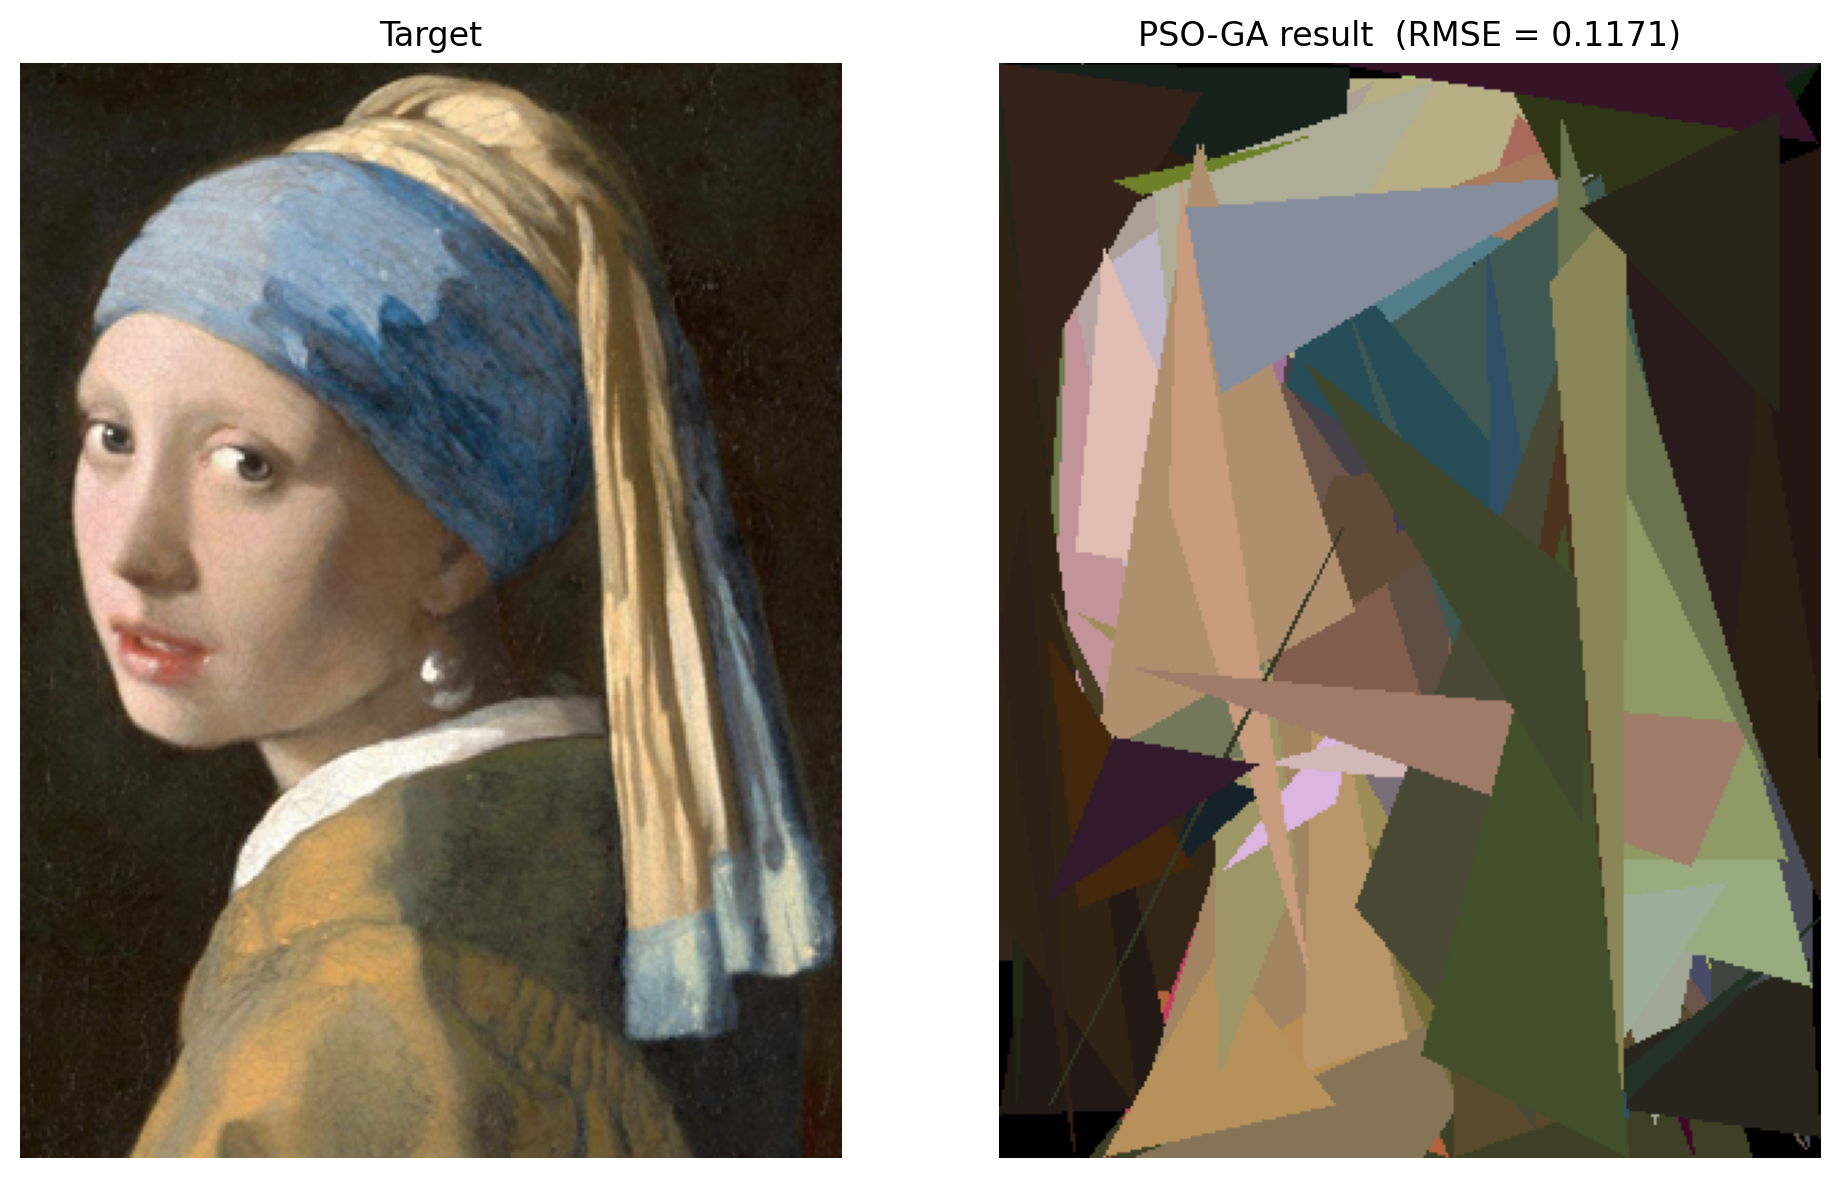

In [ ]:
from src.ga import HybridPSOGA, create_greedy_seeded_population, fitness, mutate, cross_over
from src import rendering
import matplotlib.pyplot as plt
import numpy as np

# Reuse the same greedy population built above — or rebuild it here if running standalone
greedy_population = create_greedy_seeded_population(
    target=target_array,
    population_size=200,
    n_triangles=100,
    image_width=300,
    image_height=400,
    candidates_per_triangle=200,
    verbose=True,
)

pso_ga = HybridPSOGA(
    target=target_array,
    fitness_function=fitness.compute_rmse,
    population_size=200,
    generations=300,
    n_triangles=100,
    inertia=0.9,
    inertia_min=0.4,
    c1=1.5,
    c2=1.5,
    crossover_function=cross_over.two_point_crossover,
    crossover_rate=0.7,
    mutation_function=mutate.focused_triangle_mutation,
    mutation_rate=0.08,
    local_search_steps=30,
    initial_population=greedy_population,
    evaluation_backend="process",
    n_jobs=8,
    chunksize=5,
    progress=True,
    progress_interval=10,
    max_edge_length=50
)

pso_result = pso_ga.run()
print(f"PSO-GA best fitness (RMSE): {pso_result.best_fitness:.6f}")

result_image = rendering.render_individual(
    pso_result.best_individual,
    image_width=target_array.shape[1],
    image_height=target_array.shape[0],
)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(target_array.astype(np.uint8))
axes[0].set_title("Target")
axes[0].axis("off")
axes[1].imshow(result_image)
axes[1].set_title(f"PSO-GA result  (RMSE = {pso_result.best_fitness:.4f})")
axes[1].axis("off")
plt.tight_layout()
plt.show()